Time Metric Code(XGBoost, RF,.....)

In [2]:
pip install xgboost

     -------------------------------------- 124.9/124.9 MB 4.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
# ====== 0. Force non-GUI backend ======
import matplotlib
import time
matplotlib.use('Agg')  # Avoid Tkinter errors when saving images

# ====== 1. Imports ======
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import os
import seaborn as sns

# Models
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# ====== 2. Load Data ======
train_path = "UNSW_NB15_training_grouped_balanced_hybrid.csv"
test_path  = "UNSW_NB15_testing_balanced_hybrid.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

# ====== 3. Align Columns ======
target_col = "attack_cat_grouped"
missing_in_test = set(train_df.columns) - set(test_df.columns)
for col in missing_in_test:
    if col != target_col:
        test_df[col] = 0
test_df = test_df[train_df.columns]

# ====== 4. Features & Labels ======
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_test  = test_df.drop(columns=[target_col])
y_test  = test_df[target_col]

# Identify numeric vs categorical columns
numeric_cols = X_train.select_dtypes(include=["int64","float64","bool"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

# ====== 5. Preprocessing ======
preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
])

# Label encode target
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test  = le.transform(y_test)

# ====== 6. Models to Train ======
models = {
    "XGBoost": XGBClassifier(
        objective="multi:softmax",
        num_class=len(le.classes_),
        eval_metric="mlogloss",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=500,
        multi_class="multinomial",
        solver="lbfgs",
        n_jobs=-1
    ),
    "LDA": LinearDiscriminantAnalysis()
}

# ====== 7. Directory to save plots ======
os.makedirs("feature_importance_plots", exist_ok=True)

# ====== 8. Feature Importance Plot Function ======
def plot_feature_importance(feat_names, importance, title, filename):
    indices = np.argsort(importance)[::-1]
    sorted_feat_names = [feat_names[i] for i in indices]
    sorted_importance = importance[indices]

    n_features = len(feat_names)
    plt.figure(figsize=(12, max(8, n_features * 0.3)))
    plt.barh(range(n_features), sorted_importance, align='center', color='skyblue', edgecolor='black')
    plt.yticks(range(n_features), sorted_feat_names, fontsize=10)
    plt.gca().invert_yaxis()
    plt.title(title, fontsize=16)
    plt.xlabel("Importance Score", fontsize=12)
    plt.ylabel("Features", fontsize=12)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()

    plt.figure(figsize=(12,6))
    plt.hist(sorted_importance, bins=30, color='lightgreen', edgecolor='black')
    plt.title(f"{title} Distribution", fontsize=16)
    plt.xlabel("Importance Score", fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.tight_layout()
    plt.savefig(filename.replace(".png","_distribution.png"), dpi=300, bbox_inches='tight')
    plt.close()

# ====== 9. Failure Analysis Function ======
def analyze_failures(y_true, y_pred, label_encoder, model_name):
    cm = confusion_matrix(y_true, y_pred)
    labels = label_encoder.classes_

    print(f"\n==== Failure Analysis for {model_name} ====")
    print(f"Labels: {list(labels)}")
    print("Confusion Matrix:\n", cm)

    # Visualize Confusion Matrix
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.savefig(f"feature_importance_plots/{model_name}_confusion_matrix.png", dpi=300)
    plt.close()

# ====== 10. RANDOMLY SELECT ONE TEST SAMPLE (FOR ALL MODELS) ======
random_index = np.random.randint(0, len(X_test))
single_sample = X_test.iloc[[random_index]]
single_true   = y_test[random_index]

print(f"\n🎯 Using randomly selected test sample index: {random_index}")
print(f"🧭 True Label: {le.inverse_transform([single_true])[0]}")

# ====== 11. Training, Detection on Single Sample & Feature Importance ======
timing_results = []

for name, model in models.items():
    print("\n" + "="*20)
    print(f" Training & Detecting: {name}")
    print("="*20)
    
    clf = Pipeline([
        ("preprocessor", preprocess),
        ("model", model)
    ])
    
    # --- Training ---
    start_train = time.time()
    clf.fit(X_train, y_train)
    end_train = time.time()
    train_time = end_train - start_train

    # --- Detection on same selected sample ---
    start_detect = time.time()
    y_pred = clf.predict(single_sample)
    end_detect = time.time()
    detect_time = end_detect - start_detect

    print(f"\n⏱️ Training Time: {train_time:.4f} sec")
    print(f"⚡ Single Sample Detection Time: {detect_time:.6f} sec")
    print(f"🤖 Predicted: {le.inverse_transform(y_pred)[0]}")

    print("\nClassification Report:")
    print(classification_report([single_true], y_pred, digits=3))

    print("\nConfusion Matrix:")
    print(confusion_matrix([single_true], y_pred))

    timing_results.append({
        "Model": name,
        "Training Time (s)": train_time,
        "Detection Time (s)": detect_time,
        "Per Sample (ms)": detect_time * 1000
    })

    # --- Feature Importance ---
    if name in ["XGBoost", "Random Forest", "Logistic Regression"]:
        feature_names = numeric_cols.copy()
        if categorical_cols:
            cat_features = clf.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)
            feature_names.extend(cat_features)

        if name in ["XGBoost", "Random Forest"]:
            importance = clf.named_steps['model'].feature_importances_
        else:
            importance = np.abs(clf.named_steps['model'].coef_[0])

        plot_feature_importance(
            feature_names,
            importance,
            title=f"{name} Feature Importance",
            filename=f"feature_importance_plots/{name}_feature_importance.png"
        )

# ====== 12. Timing Summary Table ======
print("\n\n========== 🕒 MODEL TIMING SUMMARY ==========")
summary_df = pd.DataFrame(timing_results)
print(summary_df.to_string(index=False))



🎯 Using randomly selected test sample index: 1470
🧭 True Label: Recon/Scanning

 Training & Detecting: XGBoost

⏱️ Training Time: 75.8591 sec
⚡ Single Sample Detection Time: 0.071524 sec
🤖 Predicted: Recon/Scanning

Classification Report:
              precision    recall  f1-score   support

           3      1.000     1.000     1.000         1

    accuracy                          1.000         1
   macro avg      1.000     1.000     1.000         1
weighted avg      1.000     1.000     1.000         1


Confusion Matrix:
[[1]]

 Training & Detecting: Random Forest

⏱️ Training Time: 24.9788 sec
⚡ Single Sample Detection Time: 0.038793 sec
🤖 Predicted: Recon/Scanning

Classification Report:
              precision    recall  f1-score   support

           3      1.000     1.000     1.000         1

    accuracy                          1.000         1
   macro avg      1.000     1.000     1.000         1
weighted avg      1.000     1.000     1.000         1


Confusion Matrix:
[[1]

Autoencoder

🖥️ Using device: cpu
📊 Loading and scaling datasets...
✅ Train: 256343, Val: 64085, Test: 1678

🚀 Training Started...

Epoch [1/10]  Train Loss: 0.902690 | Val Loss: 0.885054
Epoch [2/10]  Train Loss: 0.880073 | Val Loss: 0.878102
Epoch [3/10]  Train Loss: 0.875019 | Val Loss: 0.874819
Epoch [4/10]  Train Loss: 0.872180 | Val Loss: 0.872670
Epoch [5/10]  Train Loss: 0.870018 | Val Loss: 0.870441
Epoch [6/10]  Train Loss: 0.868539 | Val Loss: 0.869180
Epoch [7/10]  Train Loss: 0.867418 | Val Loss: 0.868081
Epoch [8/10]  Train Loss: 0.866431 | Val Loss: 0.867262
Epoch [9/10]  Train Loss: 0.865390 | Val Loss: 0.866440
Epoch [10/10]  Train Loss: 0.864214 | Val Loss: 0.865376

🧪 Single Sample Index: 0
📉 Reconstruction Error: 0.197541
⚠️ Threshold (95th percentile of train errors): 4.055107
✅ This sample is detected as **NORMAL**


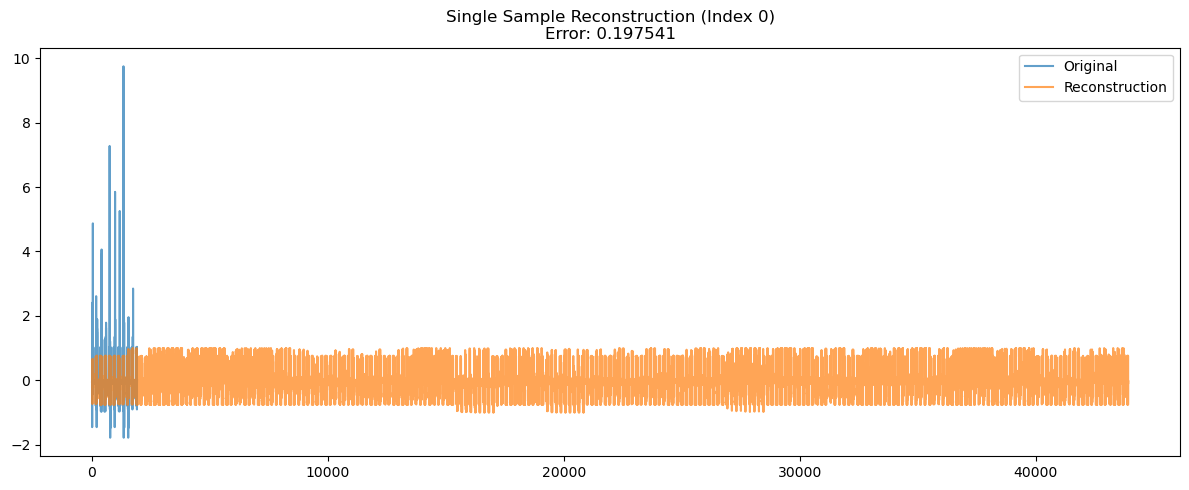

In [ ]:
# ===============================
# 1. Imports
# ===============================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ===============================
# 2. Configurations
# ===============================
train_file = "UNSW_NB15_training_grouped_balanced_hybrid.csv"
test_file  = "UNSW_NB15_testing_balanced_hybrid.csv"

batch_size = 64
sequence_len = 10
latent_dim = 64
hidden_dim = 128
num_epochs = 10
learning_rate = 1e-3
patience = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Using device: {device}")

# ===============================
# 3. Dataset Class
# ===============================
class LogDataset(Dataset):
    def __init__(self, file_path, sequence_len, scaler=None, fit_scaler=False, reference_columns=None):
        df = pd.read_csv(file_path)

        target_col = "attack_cat_grouped"
        if target_col in df.columns:
            df = df.drop(columns=[target_col])

        if reference_columns is not None:
            df = df.reindex(columns=reference_columns, fill_value=0)

        self.features = df.values.astype(np.float32)

        if scaler is None:
            scaler = StandardScaler()

        if fit_scaler:
            self.features = scaler.fit_transform(self.features)
        else:
            self.features = scaler.transform(self.features)

        self.scaler = scaler
        self.sequence_len = sequence_len
        self.samples = []

        for i in range(len(self.features) - sequence_len):
            self.samples.append(self.features[i:i+sequence_len])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x = torch.tensor(self.samples[idx], dtype=torch.float32)
        return x, x

# ===============================
# 4. Load & scale datasets
# ===============================
print("📊 Loading and scaling datasets...")

scaler = StandardScaler()

train_dataset = LogDataset(train_file, sequence_len, scaler=scaler, fit_scaler=True)
train_columns = pd.read_csv(train_file).drop(columns=["attack_cat_grouped"], errors="ignore").columns
test_dataset = LogDataset(test_file, sequence_len, scaler=scaler, fit_scaler=False, reference_columns=train_columns)

val_size = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_ds, val_ds = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"✅ Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_dataset)}")

# ===============================
# 5. Autoencoder Model
# ===============================
class SeqAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.enc_linear = nn.Linear(hidden_dim, latent_dim)
        self.dec_linear = nn.Linear(latent_dim, hidden_dim)
        self.decoder = nn.LSTM(hidden_dim, input_dim, batch_first=True)

    def forward(self, x):
        enc_out, _ = self.encoder(x)
        latent = self.enc_linear(enc_out[:, -1, :])
        dec_init = self.dec_linear(latent).unsqueeze(1).repeat(1, x.size(1), 1)
        dec_out, _ = self.decoder(dec_init)
        return dec_out, latent

input_dim = train_dataset.features.shape[1]
model = SeqAutoencoder(input_dim, hidden_dim, latent_dim).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# ===============================
# 6. Early Stopping
# ===============================
best_val_loss = np.inf
epochs_no_improve = 0

# ===============================
# 7. Training Loop
# ===============================
print("\n🚀 Training Started...\n")
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for batch_x, _ in train_loader:
        batch_x = batch_x.to(device).float()
        optimizer.zero_grad()
        recon, _ = model(batch_x)
        loss = criterion(recon, batch_x)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train = train_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, _ in val_loader:
            batch_x = batch_x.to(device).float()
            recon, _ = model(batch_x)
            loss = criterion(recon, batch_x)
            val_loss += loss.item()
    avg_val = val_loss / len(val_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {avg_train:.6f} | Val Loss: {avg_val:.6f}")

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_autoencoder.pt")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\n⏸ Early stopping triggered at epoch {epoch+1}")
            break

# ===============================
# 8. Load Best Model
# ===============================
model.load_state_dict(torch.load("best_autoencoder.pt"))
model.eval()

# ===============================
# 9. SINGLE SAMPLE Detection
# ===============================
# ====== 🔸 SINGLE SAMPLE DETECTION MOD ======
index = 0  # choose which sequence to test
single_sample, _ = test_dataset[index]
single_sample = single_sample.unsqueeze(0).to(device)  # add batch dimension

with torch.no_grad():
    recon, _ = model(single_sample)
    error = torch.mean((recon - single_sample) ** 2, dim=(1, 2)).item()

# Compute threshold (optional: from full test set)
# or set a static threshold (e.g., based on training error stats)
print(f"\n🧪 Single Sample Index: {index}")
print(f"📉 Reconstruction Error: {error:.6f}")

# ===============================
# 10. Compute threshold (optional)
# ===============================
# You can precompute threshold from train set or fixed percentile
# For simplicity, let's use train reconstruction error distribution
train_errors = []
with torch.no_grad():
    for batch_x, _ in train_loader:
        batch_x = batch_x.to(device).float()
        recon, _ = model(batch_x)
        loss = torch.mean((recon - batch_x) ** 2, dim=(1, 2))
        train_errors.extend(loss.cpu().numpy())

threshold = np.percentile(train_errors, 95)
print(f"⚠️ Threshold (95th percentile of train errors): {threshold:.6f}")

# Anomaly decision
if error > threshold:
    print("🚨 This sample is detected as an **ANOMALY**")
else:
    print("✅ This sample is detected as **NORMAL**")

# ===============================
# 11. Visualization for this sample
# ===============================
single_sample_cpu = single_sample.squeeze(0).cpu().numpy()
recon_cpu = recon.squeeze(0).cpu().numpy()

plt.figure(figsize=(12,5))
plt.plot(single_sample_cpu.flatten(), label="Original", alpha=0.7)
plt.plot(recon_cpu.flatten(), label="Reconstruction", alpha=0.7)
plt.title(f"Single Sample Reconstruction (Index {index})\nError: {error:.6f}")
plt.legend()
plt.tight_layout()
plt.savefig("single_sample_reconstruction.png", dpi=300)
plt.show()


